<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/ARIMA%20Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA Grupo México

#Librerías

In [ ]:
!pip install pmdarima

In [16]:
!pip install arch

In [17]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error

#Grupo México

In [18]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_2257/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [19]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Rendimientos

Vamos a usar los rendimientos logarítmicos para nuestros cálculos

In [20]:
#Obtener datos
precios = df['Close']

In [21]:
print(precios)

Date
2024-01-02     84.612053
2024-01-03     81.479935
2024-01-04     80.067772
2024-01-05     82.376122
2024-01-08     83.154602
                 ...    
2026-06-22    210.360001
2026-06-23    206.100006
2026-06-24    196.639999
2026-06-25    202.990005
2026-06-26    200.130005
Name: Close, Length: 622, dtype: float64


In [22]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
2026-06-26   -0.014190
Name: Rendimientos_Log, Length: 622, dtype: float64


In [23]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
2026-06-26   -0.014190
Name: Rendimientos_Log, Length: 621, dtype: float64


#ARIMA

In [24]:
#Nuestro parámetros son p=0, d=0 y q=0
#Aplicamos ARIMA con la función que ya trae Python

modelo0 = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,0))
resultado0 = modelo0.fit()

print(resultado0.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  621
Model:                          ARIMA   Log Likelihood                1480.921
Date:                Fri, 26 Jun 2026   AIC                          -2957.841
Time:                        21:26:09   BIC                          -2948.979
Sample:                             0   HQIC                         -2954.397
                                - 621                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      1.500      0.134      -0.000       0.003
sigma2         0.0005   1.54e-05     32.328      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   4.81   Jarque-

In [25]:
#Hacemos la prueba para saber si necesitamos utilizar GARCH o no
#Si p<0.5 si se requiere, si p>0.5 no se requiere

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 7.490091006657051
p-value: 0.6785075600727438


In [26]:
#Confirmaremos con Auto ARIMA que el modelo (0,0,0) es el mejor
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,1)(0,0,0)[0] intercept


In [ ]:
#Como no fue el mejor vamos a evaluar más opciones de modelos ARIMA
#El resultad con menos AIC es mejor
for orden in [(0,0,0),(0,0,1)]:
  modelo01 = ARIMA(df['Rendimientos_Log'].dropna(),order=orden)
  resultado01 = modelo01.fit()

  print(orden, resultado01.aic)

In [27]:
modelo1 = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,1))

resultado1 = modelo1.fit()

print(resultado1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  621
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1483.400
Date:                Fri, 26 Jun 2026   AIC                          -2960.801
Time:                        21:26:22   BIC                          -2947.507
Sample:                             0   HQIC                         -2955.634
                                - 621                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      1.658      0.097      -0.000       0.003
ma.L1         -0.0905      0.037     -2.441      0.015      -0.163      -0.018
sigma2         0.0005   1.57e-05     31.337      0.0

In [28]:
#Hacemos prueba para saber si se requiere GARCH o no
residuos = resultado1.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.4408612639465527
Lag=10: p-value=0.7740179567605866
Lag=15: p-value=0.9351030900082995
Lag=20: p-value=0.9786900081399025


In [29]:
#Aunque no parece necesario GARCH lo vamos a utilizar
garch = arch_model(
    residuos,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

resultado_garch = garch.fit()
print(resultado_garch.summary())

Iteration:      1,   Func. Count:      4,   Neg. LLF: -1490.046794307764
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1490.0467944148902
            Iterations: 5
            Function evaluations: 4
            Gradient evaluations: 1
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:                1490.05
Distribution:                  Normal   AIC:                          -2974.09
Method:            Maximum Likelihood   BIC:                          -2960.80
                                        No. Observations:                  621
Date:                Fri, Jun 26 2026   Df Residuals:                      621
Time:                        21:26:23   Df Model:                            0
        

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004928. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


#Predicción de Precios

In [50]:
#Predicciones pero de los rendimientos log

predictions = resultado1.forecast(steps=1)  # Predict next 5 points
print(predictions)

621    0.002586
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [51]:
#Vamos a convertir los rendimientos en precios
ultimo_precio = precios.iloc[-1]   # Último precio conocido

precios_pred = []
precio_actual = ultimo_precio

for r in predictions:
    precio_actual = precio_actual * np.exp(r)
    precios_pred.append(precio_actual)

In [52]:
precios_pred = pd.Series(precios_pred, index=predictions.index)

print(precios_pred)

621    200.648283
dtype: float64


In [53]:
precios_reales = precios[-1:]
print(precios_reales)

Date
2026-06-26    200.130005
Name: Close, dtype: float64


#Gráfica

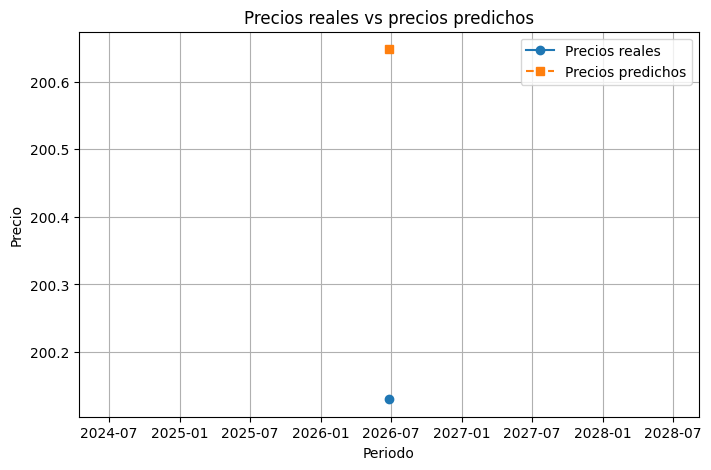

In [54]:
plt.figure(figsize=(8,5))

plt.plot(precios_reales.index, precios_reales,
         marker='o', label='Precios reales')

plt.plot(precios_reales.index, precios_pred,
         marker='s', linestyle='--', label='Precios predichos')

plt.title('Precios reales vs precios predichos')
plt.xlabel('Periodo')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

#Entrenamiento

In [55]:
train = precios[:-1]
test = precios[-1:]

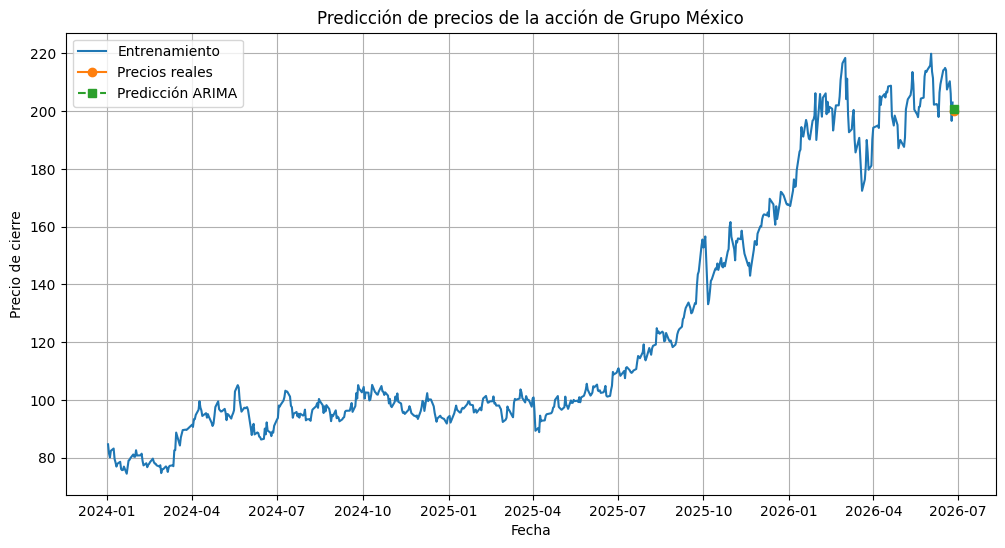

In [56]:
plt.figure(figsize=(12,6))

# Datos de entrenamiento
plt.plot(train.index, train,
         label='Entrenamiento')

# Datos reales
plt.plot(test.index, test,
         marker='o', label='Precios reales')

# Predicción
plt.plot(test.index, precios_pred,
         marker='s', linestyle='--',
         label='Predicción ARIMA')

plt.title('Predicción de precios de la acción de Grupo México')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)

plt.show()

#Estadísticos de Bondad de Ajuste

##RMSE

In [57]:
rmse = np.sqrt(mean_squared_error(precios_reales, precios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 0.52


##MAE

In [58]:
mae = mean_absolute_error(precios_reales, precios_pred)
print(f"MAE = {mae: .2f}")

MAE =  0.52


##MAPE

In [59]:
# Using scikit-learn
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(precios_reales, precios_pred) * 100
print(f"MAPE = {mape: .2f} %")

MAPE =  0.26 %


#Predicción para 29/06/26 al 04/07/26

In [60]:
predictions = resultado1.forecast(steps=6)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [61]:
ultimo_precio = precios.iloc[-1]

precios_pred = []
precio_actual = ultimo_precio

for r in predictions:
    precio_actual = precio_actual * np.exp(r)
    precios_pred.append(precio_actual)

In [62]:
fechas_pred = pd.date_range(
    start='2026-06-29',
    periods=6,
    freq='B' #Porque trabajamos con precios de la BMV
)

In [63]:
print(fechas_pred)
print(precios_pred)

DatetimeIndex(['2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02',
               '2026-07-03', '2026-07-06'],
              dtype='datetime64[ns]', freq='B')
[np.float64(200.64828272026205), np.float64(200.92700899002747), np.float64(201.20612244642817), np.float64(201.48562362731616), np.float64(201.76551307129063), np.float64(202.04579131769893)]


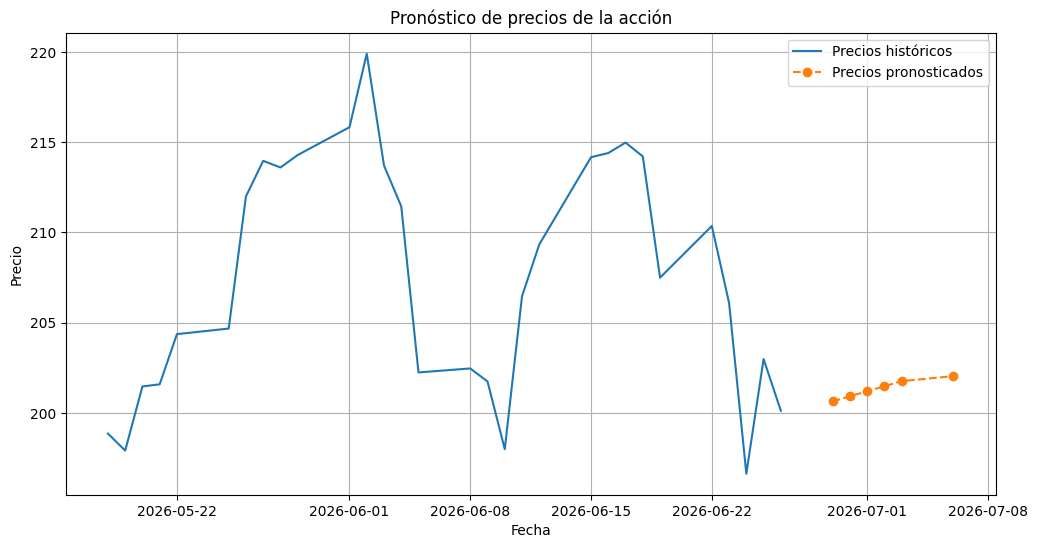

In [64]:
plt.figure(figsize=(12,6))

# Últimos precios históricos
plt.plot(precios.index[-30:], precios[-30:], label='Precios históricos')

# Predicciones
plt.plot(fechas_pred, precios_pred,
         marker='o',
         linestyle='--',
         label='Precios pronosticados')

plt.title('Pronóstico de precios de la acción')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()